In [3]:
%load_ext autoreload
%autoreload 2

import requests
import json
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from tqdm.auto import tqdm
import time
import matplotlib.pyplot as plt

from utils import (
    fetch_market_data, parse_future_name, bin_orderbook,
    compute_segment_carry, interpolate_forward, compute_continuous_forward_curve
)

In [ ]:
start_date = datetime(2025, 1, 2)
end_date = start_date + timedelta(days=2)

# Fetch futures orderbook data with depth=0 (only mid prices)
criterion = lambda filename: filename.startswith('BTC-USD-')
futures_df = fetch_market_data('6', 'FUTURES', 'BTC-USD', start_date, end_date, 'daily', depth=0, include_criterion=criterion)

Fetching FUTURES data (module=6) for BTC-USD
Period: 2025-01-02 00:00:00 to 2025-01-04 00:00:00
Split into 2 requests


Fetching data:   0%|          | 0/2 [00:00<?, ?it/s]

Fetch #1/2: 16 files found | Total: 16 files, 1700.22 MB


Fetch #2/2: 16 files found | Total: 32 files, 2944.97 MB


In [ ]:
# Fetch SWAP data for the same period with depth=0 (only mid prices)
crit
swap_df = fetch_market_data('6', 'SWAP', 'BTC-USD', start_date, end_date, 'daily', depth=0, include_criterion=criterion)


Fetching SWAP data (module=6) for BTC-USD
Period: 2025-01-01 00:00:00 to 2025-01-03 00:00:00
Split into 2 requests


Fetching data:   0%|          | 0/2 [00:00<?, ?it/s]

Fetch #1/2: 3 files found | Total: 3 files, 658.51 MB


Fetch #2/2: 3 files found | Total: 6 files, 1628.27 MB


✓ Successfully fetched 32525083 records


In [9]:
swap_df = swap_df[swap_df['symbol'] == 'BTC-USD-SWAP.OK']
print(swap_df['symbol'].unique())
print(futures_df['symbol'].unique())
for symbol in swap_df['symbol'].unique():
    print(f"{symbol}: {len(swap_df[swap_df['symbol'] == symbol])}")


['BTC-USD-SWAP.OK']
['BTC-USD-250131.OK' 'BTC-USD-250228.OK' 'BTC-USD-250110.OK'
 'BTC-USD-250103.OK' 'BTC-USD-250627.OK' 'BTC-USD-250328.OK']
BTC-USD-SWAP.OK: 12082766


In [10]:
for col in swap_df.columns:
    print(f"{col}: {swap_df[col].dtype}, {swap_df[col].nunique()} unique values, with {swap_df[col].isna().sum()} NA")

for symbol in swap_df['symbol'].unique():
    lag = swap_df.loc[swap_df['symbol'] == symbol, 'exchTimeMs'] - swap_df.loc[swap_df['symbol'] == symbol, 'timeMs']
    print(f"{symbol} - Average lag: {lag.mean() / 1000}s, max lag: {lag.min() / 1000}s")


timeMs: int64, 12082495 unique values, with 0 NA
exchTimeMs: int64, 12082766 unique values, with 0 NA
symbol: object, 1 unique values, with 0 NA
mid_price: float64, 54515 unique values, with 0 NA
BTC-USD-SWAP.OK - Average lag: -0.001954193766559743s, max lag: -0.904s


In [11]:
# Bin to 1-minute intervals
binned_swap_df = bin_orderbook(swap_df, '1min')
binned_futures_df = bin_orderbook(futures_df, '1min')

# Parse expiry from futures symbols
binned_futures_df[['underlying', 'expiry']] = binned_futures_df['symbol'].apply(
    lambda x: pd.Series(parse_future_name(x))
)

print(f"Swap records: {len(binned_swap_df)}")
print(f"Futures records: {len(binned_futures_df)}")
print(f"Unique futures symbols: {binned_futures_df['symbol'].nunique()}")
print(f"Time range: {binned_swap_df['time_bin'].min()} to {binned_swap_df['time_bin'].max()}")

Swap records: 2880
Futures records: 17280
Unique futures symbols: 6
Time range: 2025-01-01 00:01:00 to 2025-01-03 00:00:00


In [13]:
# Example: Compute segment carry for a single timestamp
example_time = binned_swap_df['time_bin'].iloc[0]
swap_mid = binned_swap_df[binned_swap_df['time_bin'] == example_time]['mid_price'].iloc[0]
futures_at_time = binned_futures_df[binned_futures_df['time_bin'] == example_time].copy()

segments = compute_segment_carry(futures_at_time, swap_mid, example_time)
print(f"\nSegment carry rates at {example_time}:")
print(segments[['symbol_start', 'symbol_end', 'T_start', 'T_end', 'carry_rate_pct']].to_string(index=False))


Segment carry rates at 2025-01-01 00:01:00:
     symbol_start        symbol_end  T_start    T_end  carry_rate_pct
             SPOT BTC-USD-250103.OK 0.000000 0.006386       18.228010
BTC-USD-250103.OK BTC-USD-250110.OK 0.006386 0.025551       11.136707
BTC-USD-250110.OK BTC-USD-250131.OK 0.025551 0.083046        9.871493
BTC-USD-250131.OK BTC-USD-250228.OK 0.083046 0.159706       12.537717
BTC-USD-250228.OK BTC-USD-250328.OK 0.159706 0.236366       11.996198
BTC-USD-250328.OK BTC-USD-250627.OK 0.236366 0.485510       11.561143


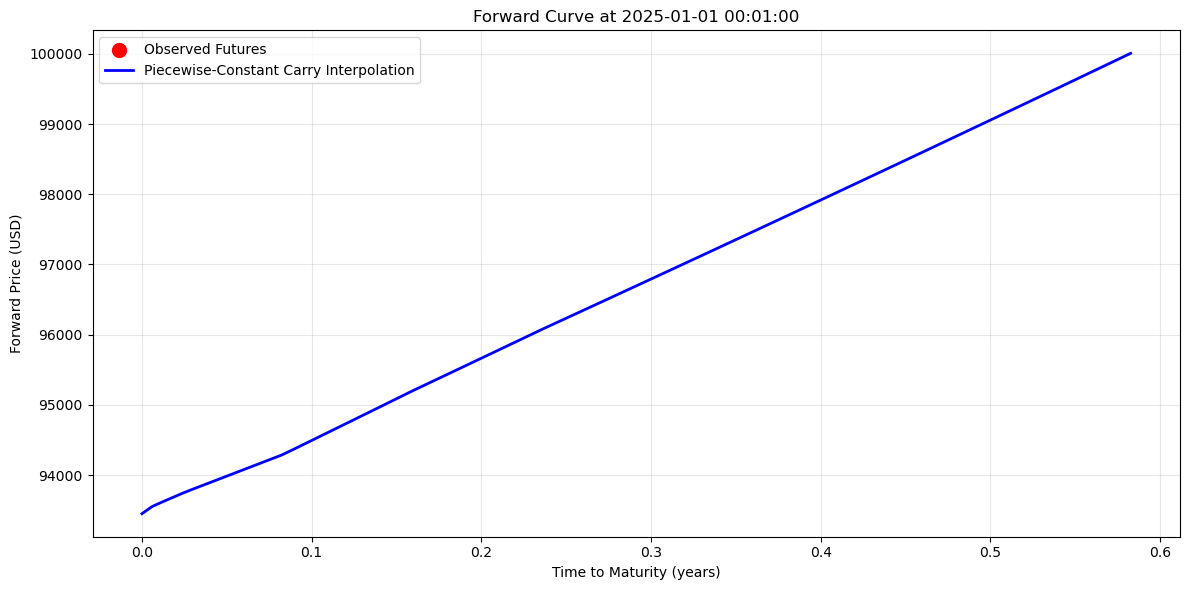


Forward curve computed with 100 points


In [15]:
# Compute continuous forward curve at the example timestamp
# Create a fine grid of maturities for interpolation
T_max = segments['T_end'].max()
T_grid = np.linspace(0, T_max * 1.2, 100)  # Extend 20% beyond last observed maturity

forward_curve = compute_continuous_forward_curve(futures_at_time, swap_mid, example_time, T_grid)

# Visualize the forward curve
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot observed futures
observed = forward_curve[forward_curve['source'] == 'observed']
interpolated = forward_curve[forward_curve['source'].isin(['interpolated', 'spot'])]

ax.scatter(observed['T'], observed['F'], color='red', s=100, zorder=3, label='Observed Futures')
ax.plot(interpolated['T'], interpolated['F'], 'b-', linewidth=2, label='Piecewise-Constant Carry Interpolation')

ax.set_xlabel('Time to Maturity (years)')
ax.set_ylabel('Forward Price (USD)')
ax.set_title(f'Forward Curve at {example_time}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nForward curve computed with {len(forward_curve)} points")

In [17]:
# Compute segment carry rates over all timestamps
all_segments = []

for _, swap_row in binned_swap_df.iterrows():
    time_bin = swap_row['time_bin']
    swap_mid = swap_row['mid_price']
    
    futures_at_time = binned_futures_df[binned_futures_df['time_bin'] == time_bin].copy()
    
    if len(futures_at_time) == 0:
        continue
    
    segments_df = compute_segment_carry(futures_at_time, swap_mid, time_bin)
    segments_df['time_bin'] = time_bin
    all_segments.append(segments_df)

all_segments_df = pd.concat(all_segments, ignore_index=True)

print(f"\nComputed {len(all_segments_df)} segment observations across time")
print(f"Time range: {all_segments_df['time_bin'].min()} to {all_segments_df['time_bin'].max()}")


Computed 17280 segment observations across time
Time range: 2025-01-01 00:01:00 to 2025-01-03 00:00:00


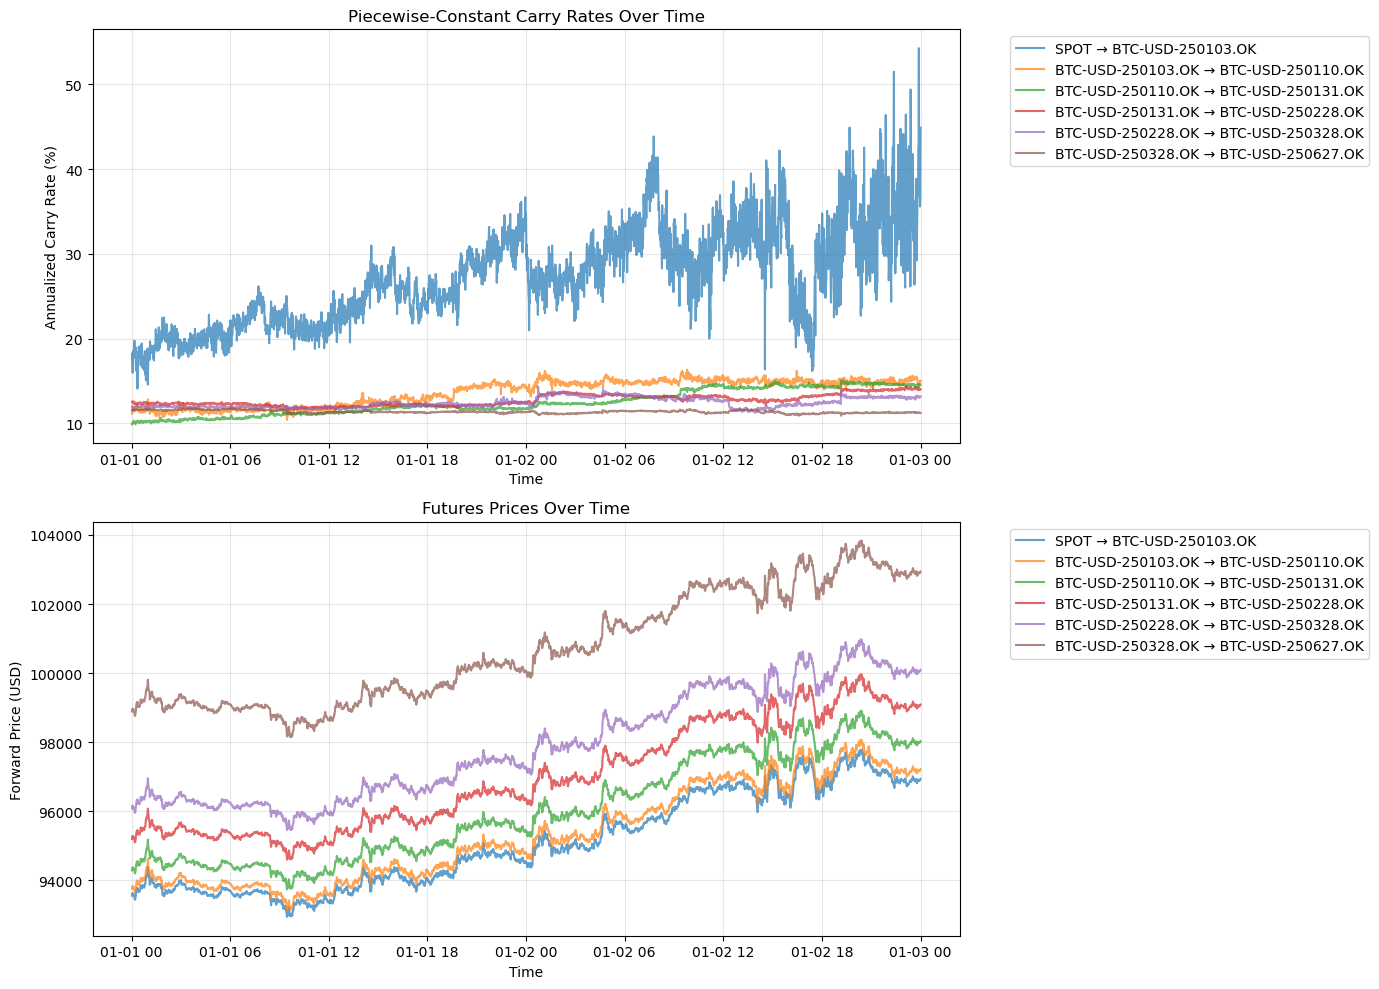

In [18]:
# Visualize carry rates over time for different segments
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Group by segment (from symbol_start to symbol_end)
all_segments_df['segment_label'] = all_segments_df['symbol_start'] + ' → ' + all_segments_df['symbol_end']

# Plot carry rates for each segment
for segment_label in all_segments_df['segment_label'].unique():
    segment_data = all_segments_df[all_segments_df['segment_label'] == segment_label]
    axes[0].plot(segment_data['time_bin'], segment_data['carry_rate_pct'], 
                 label=segment_label, alpha=0.7, linewidth=1.5)

axes[0].set_xlabel('Time')
axes[0].set_ylabel('Annualized Carry Rate (%)')
axes[0].set_title('Piecewise-Constant Carry Rates Over Time')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot forward prices (F_end) for each segment
for segment_label in all_segments_df['segment_label'].unique():
    segment_data = all_segments_df[all_segments_df['segment_label'] == segment_label]
    axes[1].plot(segment_data['time_bin'], segment_data['F_end'], 
                 label=segment_label, alpha=0.7, linewidth=1.5)

axes[1].set_xlabel('Time')
axes[1].set_ylabel('Forward Price (USD)')
axes[1].set_title('Futures Prices Over Time')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Summary statistics of carry rates by segment
summary = all_segments_df.groupby('segment_label').agg({
    'carry_rate_pct': ['mean', 'std', 'min', 'max'],
    'T_start': 'first',
    'T_end': 'first'
}).round(4)

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.sort_values('T_start_first')

print("\nCarry Rate Statistics by Segment:")
print(summary)